# 🛡️ Challenge : Prédiction des Victoires Pokémon

Ce notebook analyse les combats Pokémon pour prédire le taux de réussite basé sur les statistiques de base.

### 1. Préparation et Nettoyage des Données
Nous chargeons les données, corrigeons les valeurs manquantes (comme Primeape #62) et calculons la variable cible : le `Win_Percentage`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

# Chargement des fichiers locaux
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')

# Nettoyage
pokemon['Name'] = pokemon['Name'].fillna('Primeape') # Correction pour le #62
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# Calcul du taux de victoire (Correction de la casse : 'pokemon' au lieu de 'Pokemon')
total_wins = combats['Winner'].value_counts()
total_battles = combats['First_pokemon'].value_counts() + combats['Second_pokemon'].value_counts()
win_percentage = (total_wins / total_battles * 100).fillna(0)

# Fusion avec le dataset principal
pokemon['Win_Percentage'] = pokemon['#'].map(win_percentage)
display(pokemon.head())

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,56.000000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,49.107143


### 2. Analyse Exploratoire & Visualisation
Identifions quels facteurs influencent le plus la victoire.

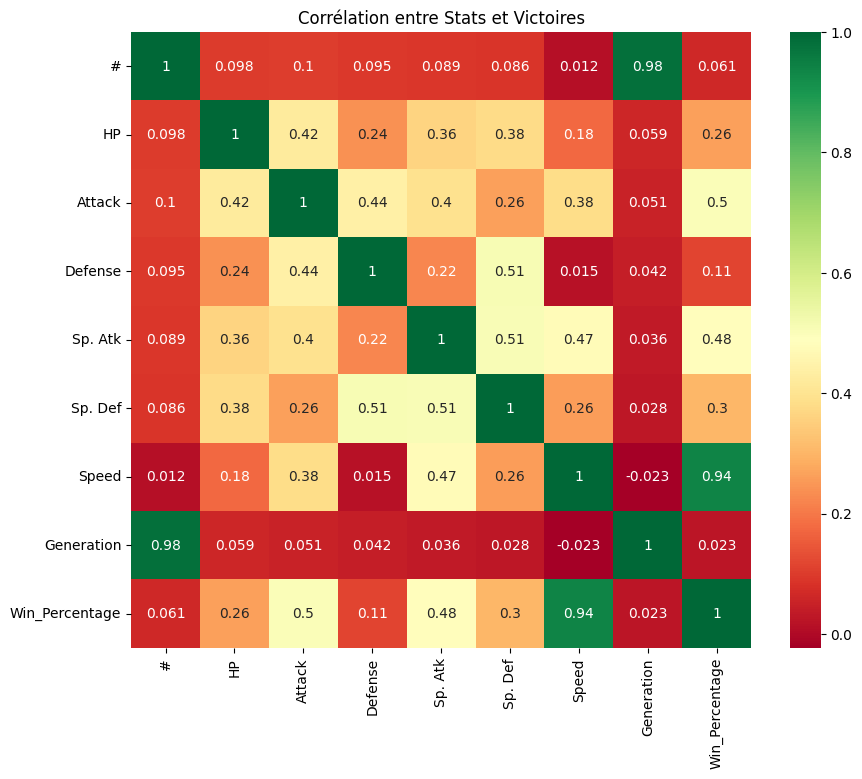

,Name,Win_Percentage,Speed,Attack
154,Mega Aerodactyl,98.449612,150,135
512,Weavile,97.478992,125,120
703,Tornadus Therian Forme,96.800000,121,100
19,Mega Beedrill,96.638655,145,150
153,Aerodactyl,96.453901,130,105
476,Mega Lopunny,96.124031,135,136
726,Greninja,96.062992,122,95
716,Meloetta Pirouette Forme,95.934959,128,128
164,Mega Mewtwo Y,95.200000,140,150
349,Mega Sharpedo,95.000000,105,140


In [14]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(pokemon.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn')
plt.title('Corrélation entre Stats et Victoires')
plt.show()

# Top 10 des meilleurs Pokémon
top_10 = pokemon.sort_values(by='Win_Percentage', ascending=False).head(10)
display(top_10[['Name', 'Win_Percentage', 'Speed', 'Attack']])

### 3. Machine Learning (Régression)
Comparaison de 3 modèles pour prédire le pourcentage de victoire.

In [16]:
# Préparation des features
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']

# Correction : Remplir les NaN dans Win_Percentage par 0 avant l'entraînement
pokemon['Win_Percentage'] = pokemon['Win_Percentage'].fillna(0)

X = pokemon[features].copy()
X['Legendary'] = X['Legendary'].astype(int)
y = pokemon['Win_Percentage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Linear Regression
lr = LinearRegression().fit(X_train, y_train)
mae_lr = mean_absolute_error(y_test, lr.predict(X_test))

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf.predict(X_test))

# 3. XGBoost
xg_reg = xgb.XGBRegressor(objective ='reg:squarederror').fit(X_train, y_train)
mae_xgb = mean_absolute_error(y_test, xg_reg.predict(X_test))

# Comparaison
results = pd.DataFrame({'Modèle': ['Linear Reg', 'Random Forest', 'XGBoost'], 'MAE': [mae_lr, mae_rf, mae_xgb]})
display(results.sort_values(by='MAE'))

,Modèle,MAE
1,Random Forest,5.764154
2,XGBoost,6.275998
0,Linear Reg,6.368675
